# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?

Linear models are linear because the variables are assumed to have a linear relationship. We assume that a line can be drawn through them, and we model this most simply in two dimensions as $\hat y = b_0 + b_1x$ where $b_0$ is the intercept and $b_1$ is the slope. The idea of a line being drawn extends beyond just two dimensions, though.

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)

The coefficients for a one-hot-encoded variable tell you, compared to one of the variable categories, how much that variable category affects the output. In the cars example in class, a coefficient of $-7000$ on the dummy variable `red` meant that being red decreased the resale value of cars by $7000 compared to what the resale value would be if the car was black.

3. Can linear regression be used for classification? Explain why, or why not.

Yes. You can turn a regression model into a classification model by setting some threshold. For example, if you are predicting mortality based on some health factors, a linear regression might output values like $0.2, 0.5,$ and $0.8$. You can set a threshold of $\geq 0.5$ to change these into $0, 1,$ and $1$ where $0$ and $1$ are different "classes" of mortality.

4. What are signs that your linear model is over-fitting?

If your MSE is very very low on your training data but not as low on your test data, that is a sign that you are overfitting. Your model is memorizing the training data and performing badly on new data — not what we want for our models.

5. Clearly explain multi-colinearity using the two-stage least squares technique.

Multi-colinearity happens when multiple input ($x$) variables are highly correlated with each other and with the output ($y$) variable. The input variables explain the same change in the output, and this leads to mushy predictions from our models. The two-stage least squares technique has the stages: 1) Pick a variable $x_k$, regress $y$ and $x_k$ on all the other variables, and save the residuals; and 2) run single linear regression on the residuals. In the first stage, if $x_k$ is highly correlated with the other variables, the variables will cancel each other out and mess up the second stage. In other words, the inputs cancel each other out, and you end up with a model with low predictive power.

6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?

We can use polynomial expansion to include relationships between different independent variables in our analysis. Multiplying the response variables together allows us to capture more in our feature space. In feature engineering, we can also use techiniques like one-hot-encoding, logarithm transforming, and normalization.

7. What is the interpretation of the slope coefficient in a linear regression?

The slope coefficient in a linear regression tells us the effect that some input variable has on the output variable. With the heart failure dataset, for example, a coefficient of $0.5$ on age would mean that the chance of heart failure goes up by about $0.5$ on average when that someone gets one year older.

8. Compare the train/test split and $k$-fold cross validation.

A train test split divides your data into a training group and a testing group. The model is built using the training data and evaluated based on the testing data. The former is used to fit the model, and the latter is used to see how the model performs on data it hasn't seen before. $k$-fold cross validation is similar to a train-test split, but it does more dividing of the data. The data is divided into $k$ number of equally-sized folds. In the first iteration, the first fold is used as the testing data and the rest of the folds are used as the training data. In the second iteration, the second fold is used for testing and the rest are used for training, and so on. Thus, the train-test split and $k$-fold cross validation methods are similar in that they both divide the data, but different in how many times they do so.

9. How is the $k$ in $k$-fold cross validation typically selected?

The $k$ in $k$-fold cross validation is based on a bias-variance tradeoff. If you choose a $k$ that is higher, you will get less bias but more variance and runtime. If you choose a $k$ that is lower, then you'll get more bias but less variance and runtime. $k$ is thus typically selected to, as best as possible, minimize bias and variance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

In [2]:
nyc = pd.read_csv('../data/Q1_clean.csv')
nyc.rename(columns={'Neighbourhood ': 'Neighborhood'}, inplace=True)
nyc.head()

,Price,Review Scores Rating,Neighborhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.

In [3]:
nyc.groupby('Neighborhood')['Price'].mean()

Neighborhood
Bronx             75.276498
Brooklyn         127.747378
Manhattan        183.664286
Queens            96.857233
Staten Island    146.166667
Name: Price, dtype: float64

Staten Island is the most expensive bourough on average.

In [4]:
nyc.groupby('Neighborhood')['Review Scores Rating'].mean()

Neighborhood
Bronx            91.654378
Brooklyn         92.363497
Manhattan        91.801496
Queens           91.549057
Staten Island    90.843750
Name: Review Scores Rating, dtype: float64

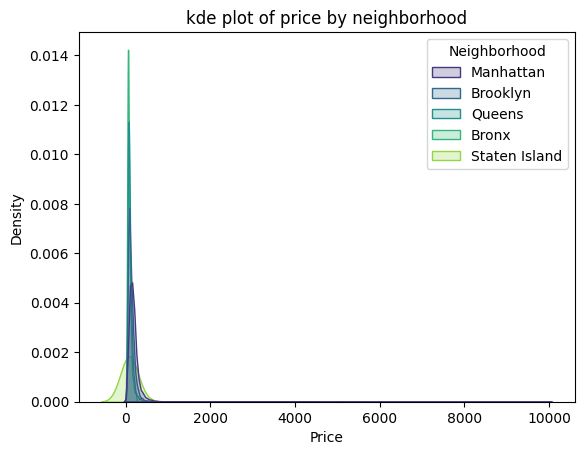

In [5]:
sns.kdeplot(nyc, x='Price', hue='Neighborhood', common_norm=False, fill=True, palette='viridis')
plt.title('kde plot of price by neighborhood')
plt.show()

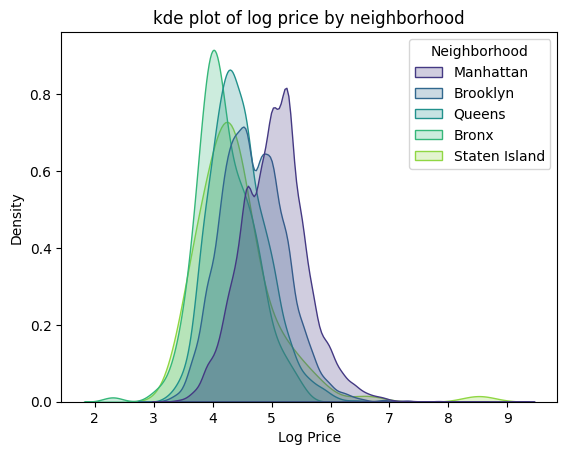

In [6]:
nyc['Log Price'] = np.log(nyc['Price'])
sns.kdeplot(nyc, x='Log Price', hue='Neighborhood', common_norm=False, fill=True, palette='viridis')
plt.title('kde plot of log price by neighborhood')
plt.show()

2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?

In [7]:
X_Neighborhood = pd.get_dummies(nyc['Neighborhood'], dtype='int', drop_first=True)
y = nyc['Price']

model_neighborhood = LinearRegression()
model_neighborhood.fit(X_Neighborhood, y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [8]:
coefs_neighborhoods = pd.DataFrame({'variable': model_neighborhood.feature_names_in_, 'coefficient': model_neighborhood.coef_ })
coefs_neighborhoods['addition with Bronx mean price'] = coefs_neighborhoods['coefficient'] + nyc[nyc['Neighborhood'] == 'Bronx']['Price'].mean()
coefs_neighborhoods

,variable,coefficient,addition with Bronx mean price
0,Brooklyn,52.470881,127.747378
1,Manhattan,108.387789,183.664286
2,Queens,21.580735,96.857233
3,Staten Island,70.890169,146.166667


The conditional group means are equal to the estimated coefficients plus the Bronx mean price.

3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.

In [26]:
X_Review_Scores_Rating = pd.DataFrame(nyc['Review Scores Rating'])

model_ratings = LinearRegression()
model_ratings.fit(X_Review_Scores_Rating, y)
coefs_ratings = pd.DataFrame({'variable': model_ratings.feature_names_in_, 'coefficient': model_ratings.coef_ })
coefs_ratings


,variable,coefficient
0,Review Scores Rating,1.020827


The slope coefficient is about $1.021$. This means that when the `Review Score Rating` goes up by $1$, the `Price` goes up by about $1.021$.

4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?

In [10]:
X_Neighborhood_and_Rating = pd.concat([X_Neighborhood, X_Review_Scores_Rating], axis=1)

model_both = LinearRegression()
model_both.fit(pd.DataFrame(X_Neighborhood_and_Rating), y)
coefs_both = pd.DataFrame({'variable': model_both.feature_names_in_, 'coefficient': model_both.coef_ })
coefs_both['past coefficient'] = pd.concat([coefs_neighborhoods['coefficient'], coefs_ratings['coefficient']], axis=0, ignore_index=True)
coefs_both['difference'] = coefs_both['coefficient'] - coefs_both['past coefficient']
coefs_both

,variable,coefficient,past coefficient,difference
0,Brooklyn,51.704240,52.470881,-0.766640
1,Manhattan,108.228737,108.387789,-0.159052
2,Queens,21.694600,21.580735,0.113865
3,Staten Island,71.766552,70.890169,0.876383
4,Review Scores Rating,1.081116,1.020827,0.060290


The slope coefficient on `Review Scores Rating` goes up to about $1.081$, and the neighborhood averages also change slightly. The coefficients for `Brooklyn` and `Manhattan` went down, and those of `Queens` and `Staten Island` went up.

5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?


In [21]:
coefs_by_neighborhood = pd.DataFrame({
    'neighborhood': nyc['Neighborhood'].unique(),
    'review scores rating coef': [0.0, 0.0, 0.0, 0.0, 0.0]
})
coefs_by_neighborhood = coefs_by_neighborhood.set_index('neighborhood')

In [22]:
for neighborhood in nyc['Neighborhood'].unique():
    one_neighborhood = nyc[nyc['Neighborhood'] == neighborhood]
    x_one_neighborhood_ratings = one_neighborhood['Review Scores Rating']
    y_one_neighborhood = one_neighborhood['Price']

    model_for_one_neighborhood = LinearRegression()
    model_for_one_neighborhood = model_for_one_neighborhood.fit(pd.DataFrame(x_one_neighborhood_ratings), y_one_neighborhood)

    coef_for_one_neighborhood = pd.DataFrame({'variable': model_for_one_neighborhood.feature_names_in_, 'coefficient': model_for_one_neighborhood.coef_ })
    coefs_by_neighborhood.loc[neighborhood, 'review scores rating coef'] = coef_for_one_neighborhood.loc[0, 'coefficient']

coefs_by_neighborhood

,review scores rating coef
neighborhood,
Manhattan,1.304014
Brooklyn,1.315476
Queens,0.502017
Bronx,0.574311
Staten Island,-31.257437


The slopes are very much different across neighborhoods. This means that the rating of a property has a varying effect on the price of the property depending on what neightborhood you are in. In `Brooklyn`, for example, an increase of $1$ in the rating contributes to an increase of about $1.315$ in the price. However, that same rating increase in `Staten Island` contributes to a price decrease of about $31.257$.

6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [23]:
cross_val_scores = pd.DataFrame({
    'model': ['neighborhood', 'ratings', 'both'],
    'average rmse': [0.0, 0.0, 0.0]
})
cross_val_scores = cross_val_scores.set_index('model')

In [28]:
kfold = KFold(n_splits=10, shuffle=True, random_state=343)

models_and_xs = [('neighborhood', model_neighborhood, X_Neighborhood), ('ratings', model_ratings, X_Review_Scores_Rating), ('both', model_both, X_Neighborhood_and_Rating)]

for index, model, X in models_and_xs:

    this_model = model
    this_X = X

    scores = cross_val_score(
        this_model, this_X, y,
        cv = kfold,
        scoring = 'neg_root_mean_squared_error'
    )
    scores = -scores

    cross_val_scores.loc[index, 'average rmse'] = np.mean(scores)

cross_val_scores

,average rmse
model,
neighborhood,138.452047
ratings,141.898631
both,138.065270


**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`. 
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1. 
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models. 
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?
